In [1]:
import torch
import pandas
import torchvision
import os
from torch.utils.data import Dataset,DataLoader
import scipy.io as scio
# Hyper parameters
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  # 添加这一行引入torch.nn.functional模块
import copy
import numpy as np
import matplotlib
import time
import h5py
from matplotlib import animation
from sklearn.metrics import confusion_matrix
from matplotlib.animation import FuncAnimation
from matplotlib import pyplot as plt
import hiddenlayer as hl
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
class MyDataset(Dataset):
    def __init__(self, root, sets):
        f = h5py.File(root, 'r')
        if sets == 'train':
            self.X = f['X_train'][:]
            self.y = f['y_train'][:]
        elif sets == 'val':
            self.X = f['X_val'][:]
            self.y = f['y_val'][:]
        else:
            self.X = f['X_test'][:]
            self.y = f['y_test'][:]
        f.close()
    def __len__(self):
        return int(self.X.shape[0])

    def __getitem__(self, idx):
        x = self.X[idx].astype(np.float32)
        # 转为 Conv2d 期望的形状: (C=1, H=1024, W=1)
        if x.ndim == 1:
            x = x[np.newaxis, :, np.newaxis]
        y = int(self.y[idx])
        return x, y

In [3]:
Epoch = 300
Batch_Size = 200
Learning_Rate = 0.001

In [4]:
data_path = 'Geerdataset_SNR15.h5'
# 读取类别数量与标签映射（若存在）
with h5py.File(data_path, 'r') as hf:
    y_train_all = hf['y_train'][:]
    NUM_CLASSES = int(len(np.unique(y_train_all)))
    label_map_attr = hf.attrs.get('label_map', '')
if isinstance(label_map_attr, str) and label_map_attr:
    items = [it.split(':') for it in label_map_attr.split(',') if it]
    label_names = [None] * len(items)
    for name, idx in items:
        label_names[int(idx)] = name
else:
    label_names = [str(i) for i in range(NUM_CLASSES)]

train_dataset = MyDataset(data_path, 'train')
val_dataset = MyDataset(data_path, 'val')

# 查看训练集的结构（可选）
for i in range(min(3, len(train_dataset))):
    input_data, label_data = train_dataset[i]
    print("Train Sample ", i)
    print("Input Shape:", input_data.shape)
    print("Label:", label_data)

train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Batch_Size, shuffle=True)
# Checking the dataset
for dataset, labels in train_loader:
    print('Signals batch dimensions:', dataset.shape)
    print('Signals label dimensions:', labels.shape)
    break
print('#training num = %d' % len(train_dataset))
print('#val num = %d' % len(val_dataset))

Train Sample  0
Input Shape: (1, 1024, 1)
Label: 3
Train Sample  1
Input Shape: (1, 1024, 1)
Label: 0
Train Sample  2
Input Shape: (1, 1024, 1)
Label: 0
Signals batch dimensions: torch.Size([200, 1, 1024, 1])
Signals label dimensions: torch.Size([200])
#training num = 2200
#val num = 2200


In [5]:
class NoiseSuppressionLayer(nn.Module):
    def __init__(self, channels=1):
        super(NoiseSuppressionLayer, self).__init__()
        self.suppress = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(channels),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return x * self.suppress(x)

class CNN_LSTM_Attention(nn.Module):
    def __init__(self, num_classes=11):
        super(CNN_LSTM_Attention, self).__init__()
        # 添加噪声抑制层
        self.noise_suppression = NoiseSuppressionLayer(channels=1)
        
        # 保持原有CNN结构
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=[16, 1], stride=[7, 1], padding=0, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=[7, 1], stride=[4, 1], padding=0, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=[3, 1], stride=[2, 1], padding=0, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.lstm = nn.LSTM(input_size=17, hidden_size=64, num_layers=2, bias=False, batch_first=True)
        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=1)
        self.fully_connect = nn.Linear(64, num_classes)
        self.classifier = nn.Softmax(dim=1)

    def forward(self, x):
        # 首先通过噪声抑制层
        x = self.noise_suppression(x)
        
        # 保持原有前向传播
        residual = x
        x = self.cnn(x)
        residual = F.interpolate(residual, size=x.size()[2:], mode='nearest')
        x = x + residual
        
        y, _ = self.lstm(x.squeeze(3))
        attention_output, _ = self.attention(y, y, y)
        logits = self.fully_connect(attention_output[:, -1, :])
        probs = self.classifier(logits)
        return logits, probs


In [6]:
# 实例化模型，使用从数据集中读取的类别数
model = CNN_LSTM_Attention(num_classes=NUM_CLASSES)

In [7]:
# 定义优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_Rate)
loss_func = nn.CrossEntropyLoss()

epoch 0
Training Accuracy is  0.185
Training Accuracy is  0.200
Training Accuracy is  0.180
Training Accuracy is  0.190
Training Accuracy is  0.230
Training Accuracy is  0.195
Training Accuracy is  0.215
Training Accuracy is  0.245
Training Accuracy is  0.275
Training Accuracy is  0.180
Training Accuracy is  0.170
epoch 1
Training Accuracy is  0.170
Training Accuracy is  0.210
Training Accuracy is  0.235
Training Accuracy is  0.215
Training Accuracy is  0.185
Training Accuracy is  0.190
Training Accuracy is  0.180
Training Accuracy is  0.205
Training Accuracy is  0.195
Validation Accuracy is  0.215
Validation Accuracy is  0.160
Validation Accuracy is  0.255
Validation Accuracy is  0.240
Validation Accuracy is  0.190
Validation Accuracy is  0.200
Validation Accuracy is  0.200
Validation Accuracy is  0.235
Validation Accuracy is  0.155
Validation Accuracy is  0.210
Validation Accuracy is  0.225
Training Accuracy is  0.255
Training Accuracy is  0.225
epoch 2
Training Accuracy is  0.190
Tr

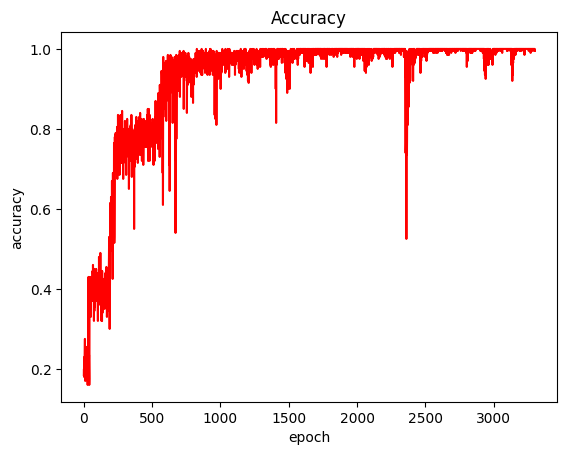

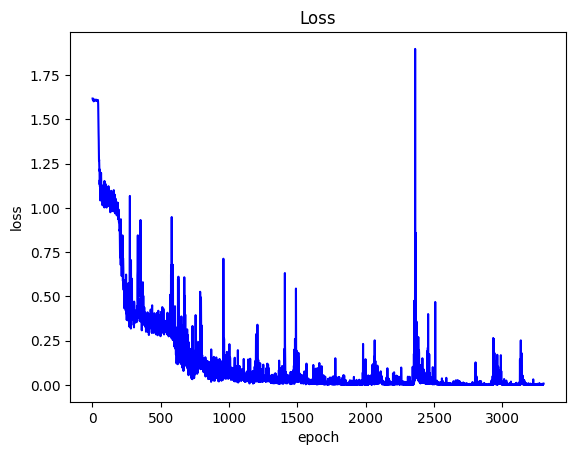

In [8]:
use_cuda = torch.cuda.is_available()
if use_cuda:
    print('CUDA is available')
device = torch.device('cuda:0' if use_cuda else "cpu")
# device = torch.device("cpu")
model = model.to(device)
# save best_model wrt. val_acc
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
Best_Acc = 0.0
loss_list = []
acc_list =[]
val_acc_list = []
val_loss_list = []
global_step = []

history = hl.History()
canvas = hl.Canvas()

for epoch in range(Epoch):
    print ("epoch", epoch)
    for step, (XTrain, YTrain) in enumerate(train_loader):
        num_correct = 0
        model.train()
        XTrain, YTrain = XTrain.float(), YTrain.long()
        XTrain, YTrain = XTrain.to(device), YTrain.to(device)
        logits, probas = model(XTrain)
        loss = loss_func(logits, YTrain)
        preds = probas.max(1, keepdim=True)[1]
        acc = preds.eq(YTrain.view_as(preds)).sum().item() / len(YTrain)
        print("Training Accuracy is %6.3f" % acc)
        loss_list.append(loss)
        acc_list.append(acc)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        global_step.append(epoch * len(train_loader) + step + 1)

        if len(global_step) % 20 == 0:
            model.eval()
            with torch.no_grad():
                for XValidation, YValidation in val_loader:
                    XValidation, YValidation = XValidation.float(), YValidation.long()
                    XValidation, YValidation = XValidation.to(device), YValidation.to(device)
                    val_logits, val_probas = model(XValidation)
                    val_loss = loss_func(val_logits, YValidation)
                    val_loss_list.append(val_loss)
                    val_preds = val_probas.max(1, keepdim=True)[1]
                    val_acc = val_preds.eq(YValidation.view_as(val_preds)).sum().item() / len(YValidation)
                    print("Validation Accuracy is %6.3f" % val_acc)
                    val_acc_list.append(val_acc)
                    if val_acc > best_acc:
                        best_acc = val_acc
                        best_model_wts = copy.deepcopy(model.state_dict())

# 存储最佳验证的模型
torch.save(best_model_wts, 'Bace_dnn_model.pkl')
#绘图
plt.figure(1)
plt.plot(global_step ,acc_list,'r-')
plt.title('Accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.savefig('Bace_dnn_acc.jpg')
plt.show()

#plt.clf()
plt.figure(2)
loss_list = [loss.cpu().detach().numpy() for loss in loss_list]  
plt.plot(global_step, loss_list, 'b-')
plt.title('Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.savefig('Bace_dnn_loss.jpg')
plt.show()

#test num = 2200
Average Test Accuracy: 21.1045%


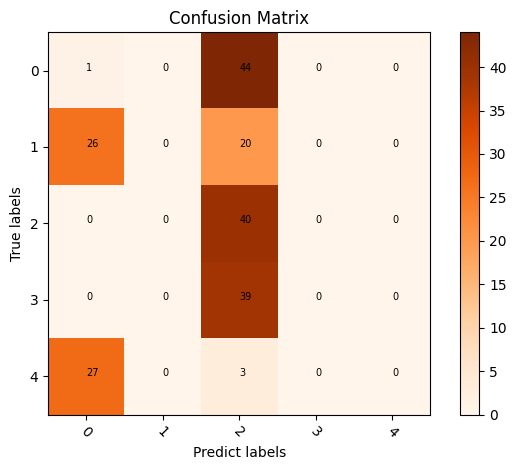

Correct_samples: 41
Total_samples: 200
Test Accuracy: 20.5000%


In [9]:
BATCH_SIZE=200 
test_acc_mean = [] 
test_dataset = MyDataset(data_path,'test')

# 查看测试集的结构
for i in range(len(test_dataset)):
    input_data, label_data = test_dataset[i]
    #print("Test Sample ", i)
    #print("Input Shape:", input_data.shape)
    #print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息
    
print('#test num = %d' % len(test_dataset))
    
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)

def restore_params(): # load the params of the net 
    models = CNN_LSTM_Attention(num_classes=NUM_CLASSES)
    models.load_state_dict(torch.load('Bace_dnn_model.pkl'))
    return models

test_acc_list = []
con_matrix = np.zeros([NUM_CLASSES, NUM_CLASSES])
for i in range(10):
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)   # BATCH_SIZE,1,1024,1
    mymodel = restore_params()
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        print('CUDA is available') 
    device = torch.device("cuda" if use_cuda else "cpu")
    mymodel = mymodel.to(device)
    for XTest, YTest in test_loader:
        XTest, YTest = XTest.float(), YTest.long()
        XTest, YTest = XTest.to(device), YTest.to(device)
        test_logits, test_probas = mymodel(XTest)
        test_preds = test_probas.max(1, keepdim=True)[1]
        test_acc = test_preds.eq(YTest.view_as(test_preds)).sum().item() / len(YTest)
        #cm = confusion_matrix(YTest, test_preds)
        cm = confusion_matrix(YTest.cpu(), test_preds.cpu())
        con_matrix += cm
        test_acc_list.append(test_acc)
        
# 计算平均测试准确率
average_test_acc = sum(test_acc_list) / len(test_acc_list)
print("Average Test Accuracy: {:.4f}%".format(average_test_acc * 100))

# visualization the Network
from matplotlib import pyplot as plt
# use label_names (from dataset) to match confusion matrix size
classes = label_names
yourconfusion = np.array(cm)
plt.imshow(yourconfusion, interpolation='nearest', cmap=plt.cm.Oranges)  #按照像素显示出矩阵
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(yourconfusion.shape[0])
plt.xticks(tick_marks, classes, rotation=-45)
plt.yticks(tick_marks, classes)
thresh = yourconfusion.max() / 2.
iters = [[i,j] for i in range(yourconfusion.shape[0]) for j in range(yourconfusion.shape[1])]
for i, j in iters:
    plt.text(j, i, format(yourconfusion[i, j]), fontsize=7)

plt.ylabel('True labels')
plt.xlabel('Predict labels')
plt.tight_layout()
plt.savefig('Bace_dnn_confusion_matrix.jpg')
plt.show()

# 根据混淆矩阵计算测试精度
true_positives = yourconfusion.diagonal().sum()
print("Correct_samples: {}".format(true_positives))
total_samples = yourconfusion.sum()
print("Total_samples: {}".format(total_samples))
test_accuracy = true_positives / total_samples
print("Test Accuracy: {:.4f}%".format(test_accuracy * 100))